# Models

In [2]:
import pandas as pd
df = pd.read_csv("../../Merged_Data/merged_flights.csv",low_memory=False)

In [18]:
df

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin_city,origin_state,dest_city,...,IS_Delay,Season,Departure_Hour,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,Date,Time,Weather_Data_Present
0,2024,1,1,1,2024-01-01,OO,3862.0,Great Falls,Montana,Salt Lake City,...,0,Winter,5,NaN,NaN,NaN,NaN,NaN,NaN,No
1,2024,1,1,1,2024-01-01,B6,148.0,Las Vegas,Nevada,New York,...,1,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No
2,2024,1,1,1,2024-01-01,WN,205.0,Las Vegas,Nevada,Portland,...,0,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No
3,2024,1,1,1,2024-01-01,WN,1881.0,Las Vegas,Nevada,Indianapolis,...,1,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No
4,2024,1,1,1,2024-01-01,WN,2675.0,Las Vegas,Nevada,Atlanta,...,1,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1343438,2024,12,31,2,2024-12-31,WN,3622.0,Columbus,Ohio,Nashville,...,0,Winter,19,NaN,NaN,NaN,NaN,NaN,NaN,No
1343439,2024,12,31,2,2024-12-31,OH,5558.0,Columbus,Ohio,Charlotte,...,0,Winter,18,NaN,NaN,NaN,NaN,NaN,NaN,No
1343440,2024,12,31,2,2024-12-31,WN,4899.0,Columbus,Ohio,Las Vegas,...,0,Winter,17,NaN,NaN,NaN,NaN,NaN,NaN,No
1343441,2024,12,31,2,2024-12-31,WN,3119.0,New Orleans,Louisiana,Burbank,...,1,Winter,13,NaN,NaN,NaN,NaN,NaN,NaN,No


## Baseline model

Predict majority class of no delay

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = df['IS_Delay']
y_pred_baseline = [0] * len(df)

print(df['IS_Delay'].value_counts())
baseline_accuracy = (df['IS_Delay'] == 0).sum() / len(df)
print(f"Accuracy: {baseline_accuracy:.3f}")
print(f"Precision: {precision_score(y_true, y_pred_baseline, zero_division=0):.3f}")
print(f"Recall: {recall_score(y_true, y_pred_baseline, zero_division=0):.3f}")
print(f"F1 score: {f1_score(y_true, y_pred_baseline, zero_division=0):.3f}")

IS_Delay
0    949747
1    393696
Name: count, dtype: int64
Accuracy: 0.707
Precision: 0.000
Recall: 0.000
F1 score: 0.000


## Correlation of target with selected features

In [20]:
from sklearn.preprocessing import LabelEncoder
df_1 = df.copy()

cols = ["month","day_of_month","day_of_week","op_unique_carrier","origin_city","origin_state",
    "dep_time","Season","Departure_Hour","IS_Delay", "Precipitation_mm"]

df_1 = df_1[cols].dropna()

#encoding
for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    df_1[col] = LabelEncoder().fit_transform(df_1[col])


corr = df_1.corr(numeric_only=True)
print(corr["IS_Delay"].sort_values(ascending=False))

IS_Delay             1.000000
dep_time             0.201703
Departure_Hour       0.159979
day_of_week          0.032353
month                0.029226
origin_state         0.019945
op_unique_carrier    0.010975
Precipitation_mm     0.001083
Season              -0.031399
day_of_month        -0.033025
origin_city         -0.047715
Name: IS_Delay, dtype: float64


# Simple decision tree bagging

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix


df_1 = df.copy()
cols = ["month","day_of_month","day_of_week", "op_unique_carrier","origin_city","origin_state","Precipitation_mm",
    "dep_time","Season","Departure_Hour","IS_Delay"]
df_1 = df_1[cols].dropna()

# Encode all at once, 
# but we don't need a label encoder for decision tree...
# removing it and replacing with category codes
 
#le = LabelEncoder()
#for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    #df_1[col] = le.fit_transform(df_1[col])
for col in ["op_unique_carrier", "origin_city", "origin_state", "Season"]:
    df_1[col] = df_1[col].astype('category').cat.codes
print(len(df_1))
X = df_1.drop("IS_Delay", axis=1)
y = df_1["IS_Delay"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
tree = DecisionTreeClassifier()

# Bagging with 5 trees
model_bag = BaggingClassifier(estimator=tree,n_estimators=5)


model_bag.fit(X_train, y_train)
y_pred = model_bag.predict(X_test)
y_proba = model_bag.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"TN: {cm[0,0]:5d}  FP: {cm[0,1]:5d}")
print(f"FN: {cm[1,0]:5d}  TP: {cm[1,1]:5d}")

108839
Accuracy: 0.815
Precision: 0.711
Recall: 0.602
F1 Score: 0.652
ROC-AUC: 0.815
              precision    recall  f1-score   support

           0       0.85      0.90      0.87     15523
           1       0.71      0.60      0.65      6245

    accuracy                           0.82     21768
   macro avg       0.78      0.75      0.76     21768
weighted avg       0.81      0.82      0.81     21768


Confusion Matrix:
TN: 13993  FP:  1530
FN:  2488  TP:  3757


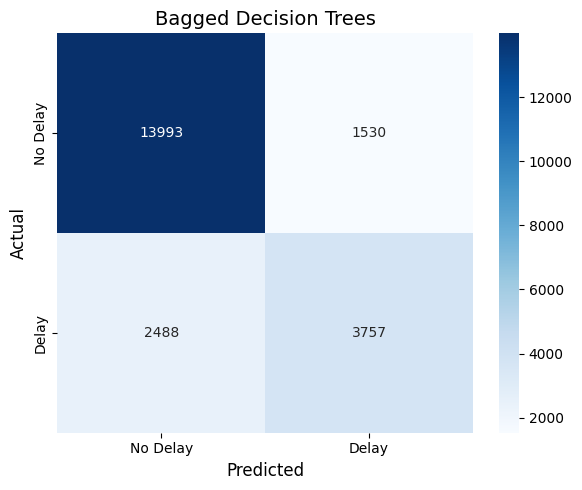

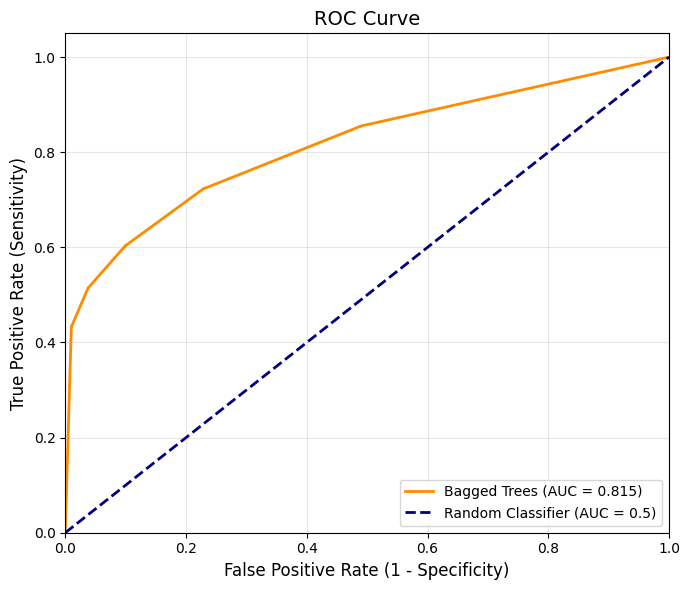

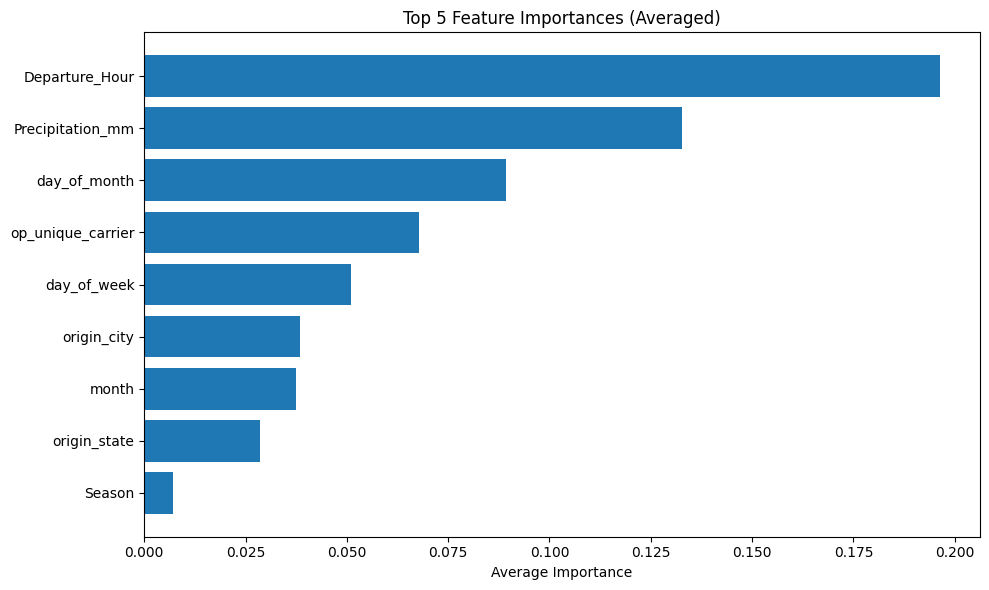

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np
# conf matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Delay', 'Delay'],yticklabels=['No Delay', 'Delay'])
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Bagged Decision Trees', fontsize=14)
plt.tight_layout()
plt.show()



# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'Bagged Trees (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


all_trees = model_bag.estimators_
# Average 
avg_importances = np.mean([tree.feature_importances_ for tree in all_trees], axis=0)
features = X.columns

# Create dataframe for easy viewing
importance_df = pd.DataFrame({'feature': features,'importance': avg_importances}).sort_values('importance', ascending=False)
importance_df = importance_df[importance_df['feature'] != 'dep_time']


# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(10)['feature'], importance_df.head(10)['importance'])
plt.xlabel('Average Importance')
plt.title('Top 5 Feature Importances (Averaged)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# KNN

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Create encoding for hour, month, day of week
def add_cyclical_features(df):
    df_cyclical = df.copy()
    
    df_cyclical['hour_sin'] = np.sin(2 * np.pi * df_cyclical['Departure_Hour'] / 24)
    df_cyclical['hour_cos'] = np.cos(2 * np.pi * df_cyclical['Departure_Hour'] / 24)
    df_cyclical['month_sin'] = np.sin(2 * np.pi * df_cyclical['month'] / 12)
    df_cyclical['month_cos'] = np.cos(2 * np.pi * df_cyclical['month'] / 12)
    df_cyclical['dow_sin'] = np.sin(2 * np.pi * df_cyclical['day_of_week'] / 7)
    df_cyclical['dow_cos'] = np.cos(2 * np.pi * df_cyclical['day_of_week'] / 7)
    
    # Drop original
    df_cyclical = df_cyclical.drop(['Departure_Hour', 'month', 'day_of_week'], axis=1)
    
    return df_cyclical

df_1 = df.copy()


# Select columns (keeping dep_time as is for now)
cols = ["month", "day_of_month", "day_of_week", "op_unique_carrier", 
        "origin_city", "origin_state", "dep_time", "Season", 
        "Departure_Hour", "IS_Delay", "Precipitation_mm"]
df_1 = df_1[cols].dropna()
# use subset maybe for demo?
# for some reason it takes way too long so I'm doing only 100k
df_1 = df_1.sample(20000, random_state=811)
print(len(df.columns))
print(f"The dataset size for KNN is: {len(df_1)}")

df_1 = add_cyclical_features(df_1)

# Convert departure time into minutes
df_1['dep_time_minutes'] = (df_1['dep_time'] // 100) * 60 + (df_1['dep_time'] % 100)
df_1 = df_1.drop('dep_time', axis=1)
# One-hot encode categorical
df_1 = pd.get_dummies(df_1, columns=["op_unique_carrier", "origin_city", "origin_state", "Season"], drop_first=True)

X = df_1.drop("IS_Delay", axis=1)
print(len(df.columns))
y = df_1["IS_Delay"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=811)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN and grid search (same as your original)
knn = KNeighborsClassifier()
param_grid = {"n_neighbors": [5, 10, 15, 20],"weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]}

grid = GridSearchCV(knn, param_grid, cv=5, return_train_score=True)

# data is split inside fit for cross validations, 5 folds
grid.fit(X_train, y_train)

results = pd.DataFrame(grid.cv_results_)
results = results[["param_n_neighbors", "param_weights", "param_metric", "mean_test_score"]]
results = results.sort_values(by="mean_test_score", ascending=False)

print(results)
print("\nBest Parameters:", grid.best_params_)
print(f"Best CV Score: {grid.best_score_:.4f}")

# Optional: Evaluate on test set
y_pred = grid.predict(X_test)
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

37
The dataset size for KNN is: 20000
37


KeyboardInterrupt: 

## Analysis of best KNN

In [19]:
best_knn = KNeighborsClassifier(n_neighbors=20, weights='uniform', metric='manhattan')
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion matrix:")
print(f"TN: {cm[0,0]:5d}  FP: {cm[0,1]:5d}")
print(f"FN: {cm[1,0]:5d}  TP: {cm[1,1]:5d}")

Accuracy:  0.722
Precision: 0.518
Recall:  0.093
F1Score: 0.158
ROC-AUC: 0.642
              precision    recall  f1-score   support

           0       0.73      0.97      0.83      1187
           1       0.52      0.09      0.16       462

    accuracy                           0.72      1649
   macro avg       0.63      0.53      0.50      1649
weighted avg       0.67      0.72      0.64      1649


Confusion matrix:
TN:  1147  FP:    40
FN:   419  TP:    43


## Hyperparameter tuning results for KNN

Results: 
        param_n_neighbors param_weights param_metric  mean_test_score

**14                 20       uniform    manhattan         0.712573 - best model**

6                  20       uniform    euclidean         0.709388

10                 10       uniform    manhattan         0.708628

12                 15       uniform    manhattan         0.707416

15                 20      distance    manhattan         0.706505

7                  20      distance    euclidean         0.706201

13                 15      distance    manhattan         0.706051

4                  15       uniform    euclidean         0.704686

2                  10       uniform    euclidean         0.704229

5                  15      distance    euclidean         0.701956

11                 10      distance    manhattan         0.695585

3                  10      distance    euclidean         0.688759

8                   5       uniform    manhattan         0.676929

9                   5      distance    manhattan         0.674350

0                   5       uniform    euclidean         0.673287

1                   5      distance    euclidean         0.671922